# Transfer Learning in CV


## Model Function


In [ ]:
import tensorflow as tf


def build_resnet_model(num_classes, image_shape=(224, 224, 3)):
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights="imagenet",
        input_shape=image_shape,
    )
    base_model.trainable = False  # freeze for feature extraction
    model = tf.keras.Sequential(
        [
            # ResNet50V2 expects specific scaling
            tf.keras.layers.Lambda(
                tf.keras.applications.resnet_v2.preprocess_input,
                input_shape=image_shape,
            ),
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    return model


def build_efficientnet_model(num_classes, image_shape=(224, 224, 3)):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=image_shape,
    )
    base_model.trainable = False  # freeze for feature extraction
    model = tf.keras.Sequential(
        [
            # EfficientNet handles its own scaling internally,
            # but expects raw [0, 255] inputs. No extra lambda layer needed!
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    return model


def train_model(model, train_data, test_data, epochs, callbacks=[]):
    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=test_data,
        callbacks=callbacks,
    )
    return history

## Transfer Learning with 100% data


In [3]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

!unzip -q 10_food_classes_all_data.zip -d 10_food_classes_all_data

data_path = './10_food_classes_all_data/10_food_classes_all_data'

--2026-07-03 18:34:09--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  18.2MB/s    in 7.6s    

2026-07-03 18:34:17 (65.5 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [4]:
train_path = data_path + "/train"
test_path = data_path + "/test"

In [ ]:
import pathlib
import numpy as np

data_dir = pathlib.Path(train_path)
classnames = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(classnames)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def view_random_image(target_dir, target_class):
    target_folder = target_dir + "/" + target_class

    random_image = random.sample(os.listdir(target_folder), 1)

    img = mpimg.imread(target_folder + "/" + random_image[0])

    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    print(f"Image shape: {img.shape}")
    plt.show()

Image shape: (512, 512, 3)


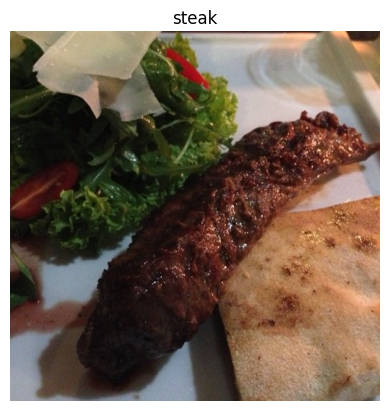

In [7]:
view_random_image(train_path, random.choice(classnames))

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Don't rescale resnet handles it automatically (see the build_model function)
# efficient net requires the image in 0-255 formattrain_datagen = ImageDataGenerator()
valid_datagen = ImageDataGenerator()

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(
    directory=train_path,
    batch_size=BATCH_SIZE,
    target_size=IMAGE_SIZE,
    class_mode="categorical",  # only 2 classes till now
    seed=42,
)
valid_data = valid_datagen.flow_from_directory(
    directory=test_path,
    batch_size=BATCH_SIZE,
    target_size=IMAGE_SIZE,
    class_mode="categorical",  # only 2 classes till now
    seed=42,
)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Training with 100% of the data


In [9]:
model_100_resnet = build_resnet_model(num_classes=len(classnames))
model_100_efficientnet = build_efficientnet_model(num_classes=len(classnames))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_100_resnet = train_model(
    model_100_resnet,
    train_data,
    valid_data,
    epochs=5,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.7140 - loss: 0.8874 - val_accuracy: 0.8192 - val_loss: 0.5474
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 130ms/step - accuracy: 0.8215 - loss: 0.5472 - val_accuracy: 0.8364 - val_loss: 0.5001
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 136ms/step - accuracy: 0.8495 - loss: 0.4485 - val_accuracy: 0.8396 - val_loss: 0.4808
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - accuracy: 0.8769 - loss: 0.3866 - val_accuracy: 0.8384 - val_loss: 0.5075
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.8944 - loss: 0.3308 - val_accuracy: 0.8500 - val_loss: 0.4683


In [ ]:
history_100_efficientnet = train_model(
    model_100_efficientnet,
    train_data,
    valid_data,
    epochs=5,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.7608 - loss: 0.8634 - val_accuracy: 0.8892 - val_loss: 0.4133
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.8584 - loss: 0.4733 - val_accuracy: 0.8992 - val_loss: 0.3352
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8773 - loss: 0.4001 - val_accuracy: 0.9088 - val_loss: 0.3070
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8905 - loss: 0.3554 - val_accuracy: 0.9080 - val_loss: 0.2962
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.9013 - loss: 0.3267 - val_accuracy: 0.9084 - val_loss: 0.2811


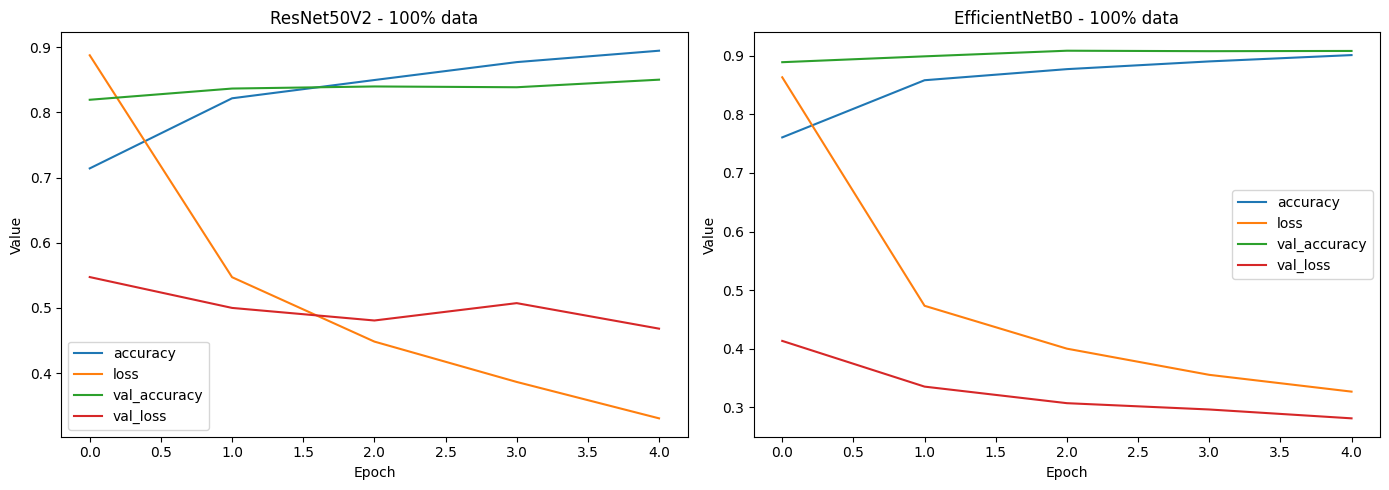

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(history_100_resnet.history).plot(ax=axes[0])
axes[0].set_title("ResNet50V2 - 100% data")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")

pd.DataFrame(history_100_efficientnet.history).plot(ax=axes[1])
axes[1].set_title("EfficientNetB0 - 100% data")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

## Training with 10% of the Training Data


In [13]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

!unzip -q 10_food_classes_10_percent.zip -d 10_food_classes_10_percent

ten_percent_data_path = './10_food_classes_10_percent/10_food_classes_10_percent'

--2026-07-03 18:41:08--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 192.178.163.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   129MB/s    in 1.2s    

2026-07-03 18:41:09 (129 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [14]:
ten_percent_train_path = ten_percent_data_path + "/train"
ten_percent_test_path = ten_percent_data_path + "/test"

In [ ]:
import pathlib
import numpy as np

ten_percent_data_dir = pathlib.Path(train_path)
ten_percent_classnames = np.array(
    sorted([item.name for item in ten_percent_data_dir.glob("*")])
)
print(ten_percent_classnames)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (512, 512, 3)


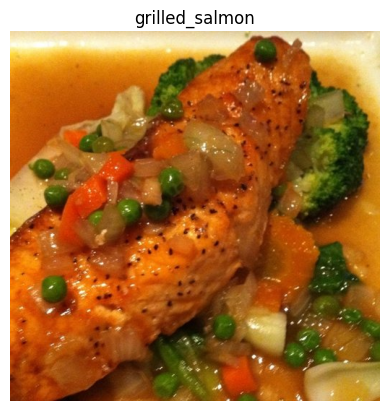

In [16]:
view_random_image(ten_percent_train_path, random.choice(ten_percent_classnames))

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Don't rescale resnet handles it automatically (see the build_model function)
# efficient net requires the image in 0-255 format
ten_percent_train_datagen = ImageDataGenerator()
ten_percent_valid_datagen = ImageDataGenerator()

# Import data from directories and turn it into batches
ten_percent_train_data = ten_percent_train_datagen.flow_from_directory(
    directory=ten_percent_train_path,
    batch_size=BATCH_SIZE,
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    seed=42,
)
ten_percent_valid_data = ten_percent_valid_datagen.flow_from_directory(
    directory=ten_percent_test_path,
    batch_size=BATCH_SIZE,
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    seed=42,
)

Found 750 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [ ]:
model_10_resnet = build_resnet_model(num_classes=len(ten_percent_classnames))
model_10_efficientnet = build_efficientnet_model(
    num_classes=len(ten_percent_classnames)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_10_resnet = train_model(
    model_10_resnet,
    ten_percent_train_data,
    ten_percent_valid_data,
    epochs=5,
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.3520 - loss: 1.9159 - val_accuracy: 0.6164 - val_loss: 1.2078
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 415ms/step - accuracy: 0.7253 - loss: 0.9062 - val_accuracy: 0.7228 - val_loss: 0.8643
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 413ms/step - accuracy: 0.8187 - loss: 0.6242 - val_accuracy: 0.7476 - val_loss: 0.7786
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 414ms/step - accuracy: 0.8693 - loss: 0.4874 - val_accuracy: 0.7600 - val_loss: 0.7118
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 389ms/step - accuracy: 0.9160 - loss: 0.3804 - val_accuracy: 0.7716 - val_loss: 0.6992


In [ ]:
history_10_efficientnet = train_model(
    model_10_efficientnet,
    ten_percent_train_data,
    ten_percent_valid_data,
    epochs=5,
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.3987 - loss: 1.8797 - val_accuracy: 0.7188 - val_loss: 1.3265
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 528ms/step - accuracy: 0.7733 - loss: 1.0929 - val_accuracy: 0.8144 - val_loss: 0.8882
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 368ms/step - accuracy: 0.8187 - loss: 0.7833 - val_accuracy: 0.8464 - val_loss: 0.7055
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 369ms/step - accuracy: 0.8560 - loss: 0.6347 - val_accuracy: 0.8532 - val_loss: 0.6213
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 0.8813 - loss: 0.5481 - val_accuracy: 0.8632 - val_loss: 0.5602


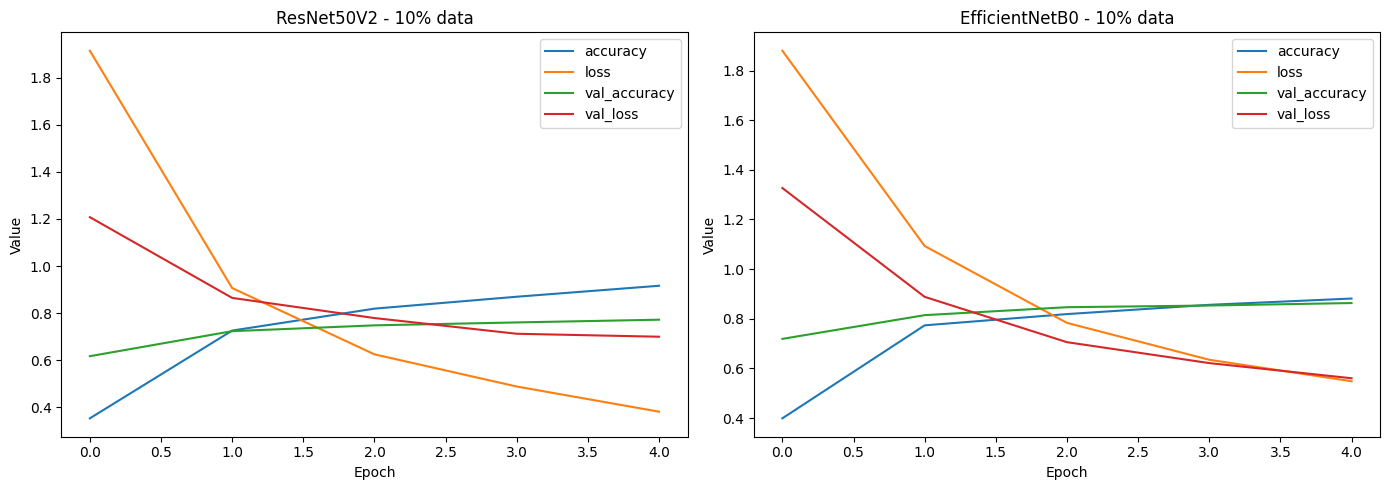

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(history_10_resnet.history).plot(ax=axes[0])
axes[0].set_title("ResNet50V2 - 10% data")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")

pd.DataFrame(history_10_efficientnet.history).plot(ax=axes[1])
axes[1].set_title("EfficientNetB0 - 10% data")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()